<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ciencias_de_Dados_Aula_16_Agrupamentos_Exemplo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5500004 Fundamentos em Ciências de Dados

## Profa. Cibele Russo - ICMC USP


## Análise de Agrupamentos - Exemplo

Fonte principal: MOREIRA, João Mendes; CARVALHO, André C. P. L. F. de; HORVÁTH, Tomáš. **A General Introduction to Data Analytics**. 1. ed. Hoboken, NJ: John Wiley & Sons, Inc., 2019.

Notebook criado com apoio de ferramentas de IA generativa: NotebookLM e ChatGPT.




Materiais complementares sugeridos:

Playlist Análise Multivariada e Aprendizado Não-Supervisionado: https://www.youtube.com/playlist?list=PLt7qVSwRVn5bg14OLl6dHTNnXVrEM6UiS

Análise de agrupamentos: https://youtu.be/zyLDAnQMnbo?si=mmd8Eck-EugqUM_o

Análise de agrupamentos - Aplicação em Python: https://youtu.be/d_CJGaAbC7o?si=2yAtCxoud7x2U-WS



Vamos avaliar alguns indicadores sócios-económicos (inflação, PIB per capita, Crescimento do PIB e desemprego) dos países no ano de 2018, disponíveis na base de dados do Banco Mundial, World_Bank.csv.

1. Descreva os dados utilizando ferramentas descritivas e exploratórias adequadas,observando a natureza das variáveis presentes no conjunto de dados.

2. Desenvolva um agrupamento hierárqico via dendrograma. Determine o número de clusters adequado. Justifique sua resposta, identificando qual foi o critério utilizado.

3. Considere um subconjunto dos dados com os seguintes países:
    Brasil, China, Uruguai, Paraguai, Chile, Peru, Bolívia, Equador, Colombia, Alemanha, Estados Unidos, Reino Unido, Polônia.

    Desenvolva analises de agrupamentos utilizando técnicas hierárquicas e não hierárquicas. Justifique adequadamente a escolha da quantidade de grupos.
    


## Agrupamento hierárquico via dendrograma

In [1]:
!pip install geopandas

In [2]:
# ! pip install descartes

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_samples
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

import geopandas

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/cibelerusso/AnaliseMultivariadaEAprendizadoNaoSupervisionado/master/Dados/World_Bank.csv",sep=' ')
df.head()

,inflacao,pib_per_capita,crescimento_pib,desemprego
United Arab Emirates,3.068147,43004.948646,1.423840,2.575
Albania,2.020790,5253.630064,4.004413,13.898
Armenia,2.520234,4212.070943,5.200000,17.712
Angola,20.190374,3432.385736,-2.133493,7.253
Austria,1.998382,51512.905475,2.729083,4.786


In [5]:
df.shape

(134, 4)

In [6]:
df.describe()

,inflacao,pib_per_capita,crescimento_pib,desemprego
count,134.000000,134.000000,134.000000,134.000000
mean,3.561733,17596.639838,3.408318,6.846358
std,3.797585,22718.772784,2.228776,5.373266
min,-2.814698,275.429603,-3.815710,0.142000
25%,1.507143,2564.751352,1.892515,3.373500
50%,2.517135,7253.779541,3.110311,5.324000
75%,4.283929,23128.944589,4.876709,8.891250
max,23.563515,114340.498742,8.671683,26.958000


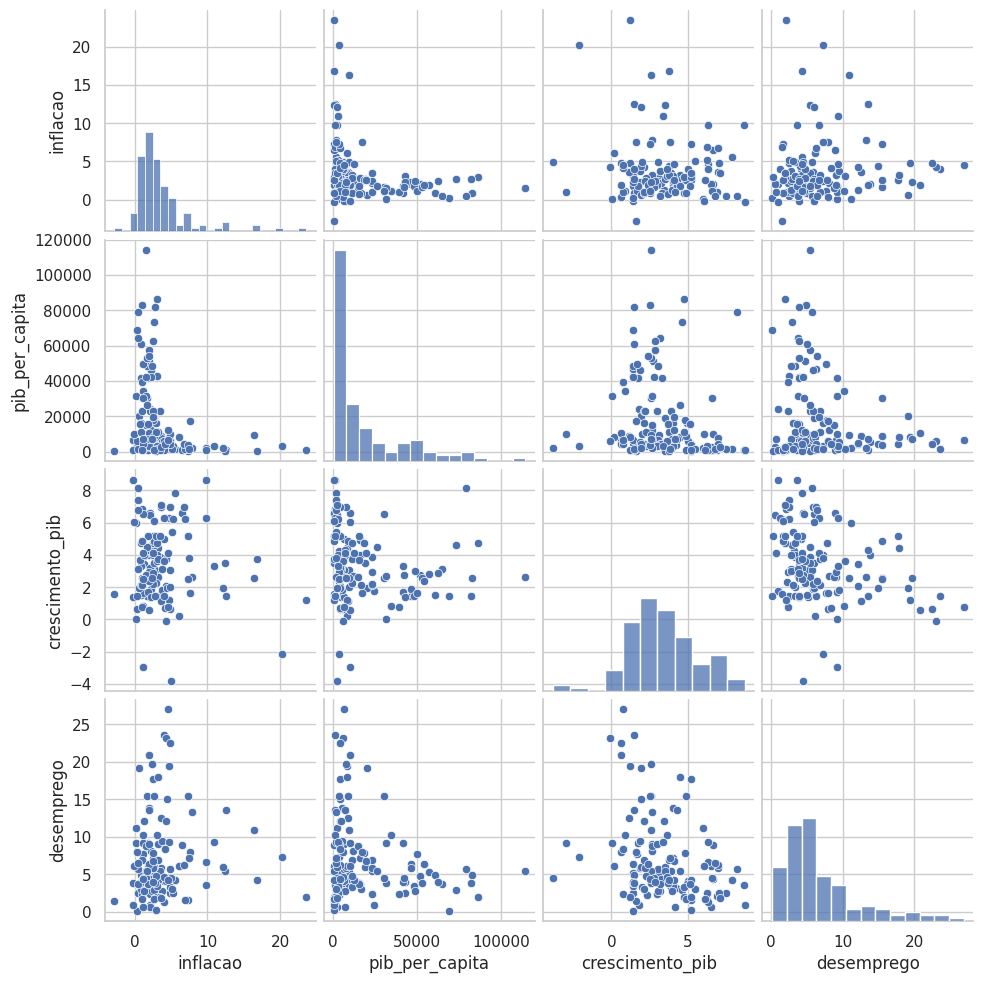

In [7]:
sns.pairplot(df)

<Axes: >

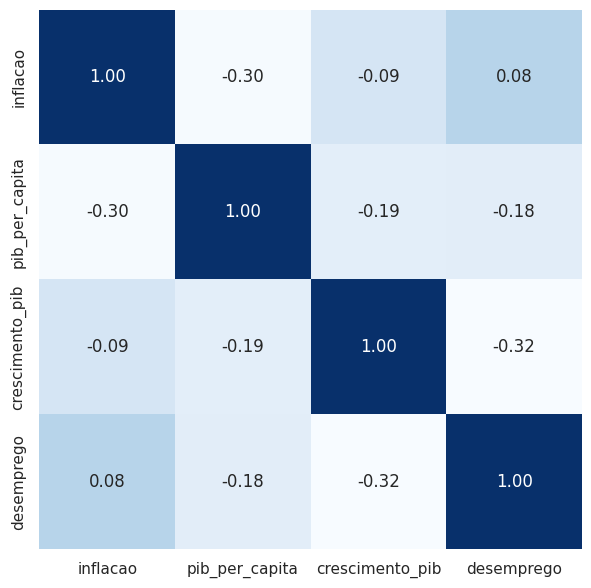

In [8]:
plt.figure(figsize=(7, 7))
corr = np.corrcoef(df.values, rowvar=False)
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', cbar=False, xticklabels=df.columns, yticklabels=df.columns)

In [9]:
df_scaled = df.copy()
df_scaled.iloc[:, :] = StandardScaler().fit_transform(df)


## 1. Matriz de distâncias

A análise de agrupamentos começa pela ideia de **proximidade** entre observações. Como as variáveis estão em escalas diferentes, primeiro padronizamos os dados e depois calculamos as distâncias entre os países.

Aqui vamos usar a **distância Euclidiana**, definida por

$$
d(x_i,x_j)=\sqrt{\sum_{p=1}^{P}(x_{ip}-x_{jp})^2}.
$$

Na matriz de distâncias:

- a diagonal é igual a zero, pois cada país tem distância zero em relação a ele mesmo;
- a matriz é simétrica;
- quanto menor a distância, mais semelhantes são os países segundo as variáveis analisadas.

In [10]:
# Matriz de distâncias entre todos os países
matriz_distancias = pairwise_distances(df_scaled, metric="euclidean")

matriz_distancias_df = pd.DataFrame(
    matriz_distancias,
    index=df_scaled.index,
    columns=df_scaled.index
)

matriz_distancias_df.iloc[:10, :10]

,United Arab Emirates,Albania,Armenia,Angola,Austria,Australia,Azerbaijan,Bangladesh,Belgium,Burkina Faso
United Arab Emirates,0.000000,2.946742,3.721072,5.183484,0.858709,1.082807,1.787993,3.503575,7.660477e-01,3.042968
Albania,2.946742,0.000000,0.903928,5.679101,2.721112,2.845126,1.997840,2.668690,2.582331e+00,1.859870
Armenia,3.721072,0.903928,0.000000,6.044796,3.384556,3.458875,2.894827,2.891318,3.303383e+00,2.267218
Angola,5.183484,5.679101,6.044796,0.000000,5.713250,5.842588,5.100370,5.963793,5.406357e+00,6.219210
Austria,0.858709,2.721112,3.384556,5.713250,0.000000,0.284429,2.152261,3.328259,6.846763e-01,2.826795
Australia,1.082807,2.845126,3.458875,5.842588,0.284429,0.000000,2.410115,3.482433,8.083445e-01,3.000442
Azerbaijan,1.787993,1.997840,2.894827,5.100370,2.152261,2.410115,0.000000,3.066500,1.860142e+00,2.307592
Bangladesh,3.503575,2.668690,2.891318,5.963793,3.328259,3.482433,3.066500,0.000000,3.646330e+00,1.194267
Belgium,0.766048,2.582331,3.303383,5.406357,0.684676,0.808344,1.860142,3.646330,2.980232e-08,3.053135
Burkina Faso,3.042968,1.859870,2.267218,6.219210,2.826795,3.000442,2.307592,1.194267,3.053135e+00,0.000000


### Visualização da matriz de distâncias

O mapa de calor permite visualizar pares ou blocos de países mais semelhantes. Cores mais claras ou mais escuras, dependendo da escala usada, indicam distâncias menores ou maiores.

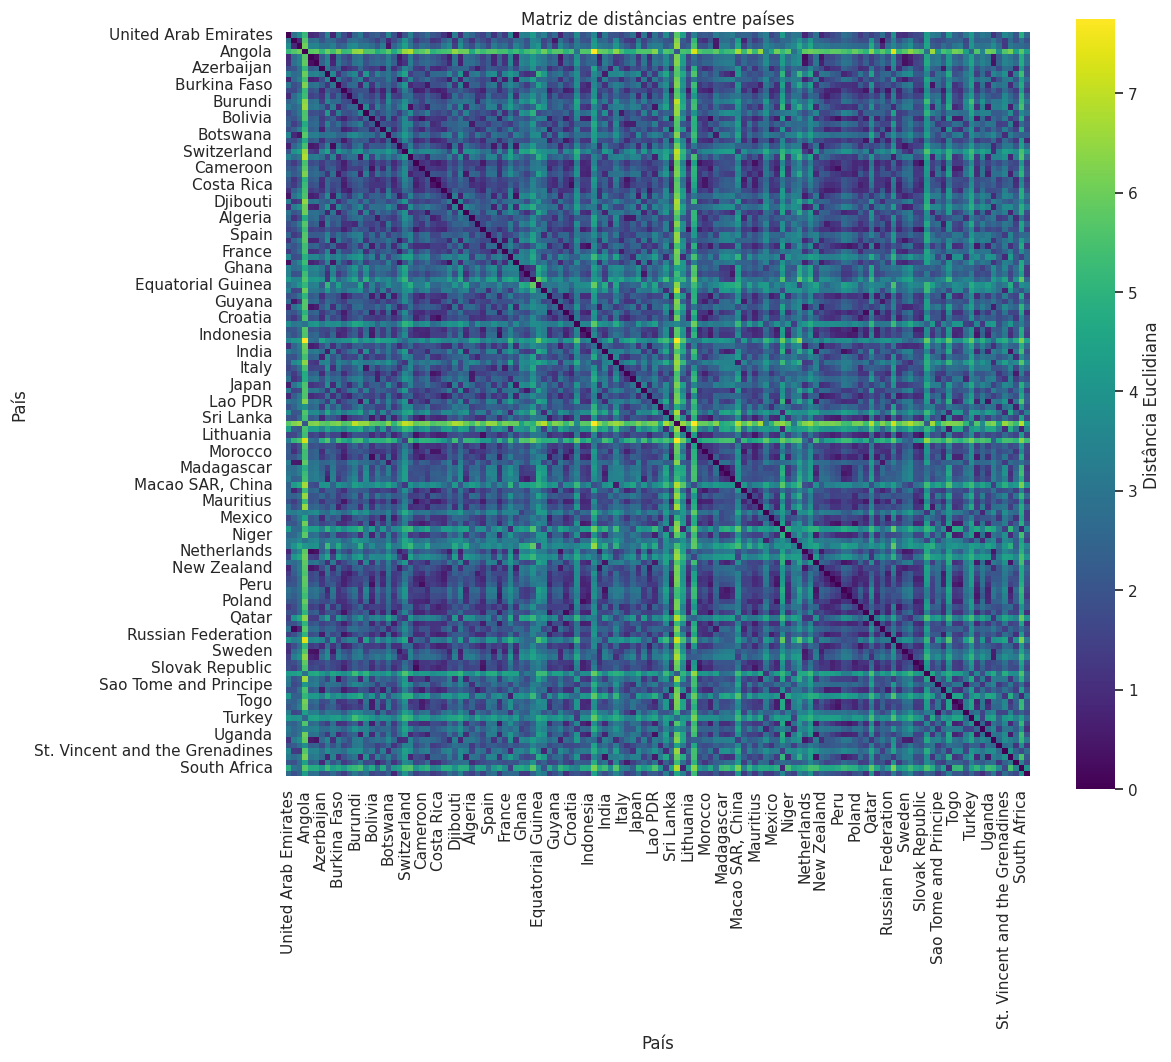

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_distancias_df,
    cmap="viridis",
    square=True,
    cbar_kws={"label": "Distância Euclidiana"}
)
plt.title("Matriz de distâncias entre países")
plt.xlabel("País")
plt.ylabel("País")
plt.show()

Como há muitos países, também é útil olhar apenas para o subconjunto de países de interesse definido no enunciado.

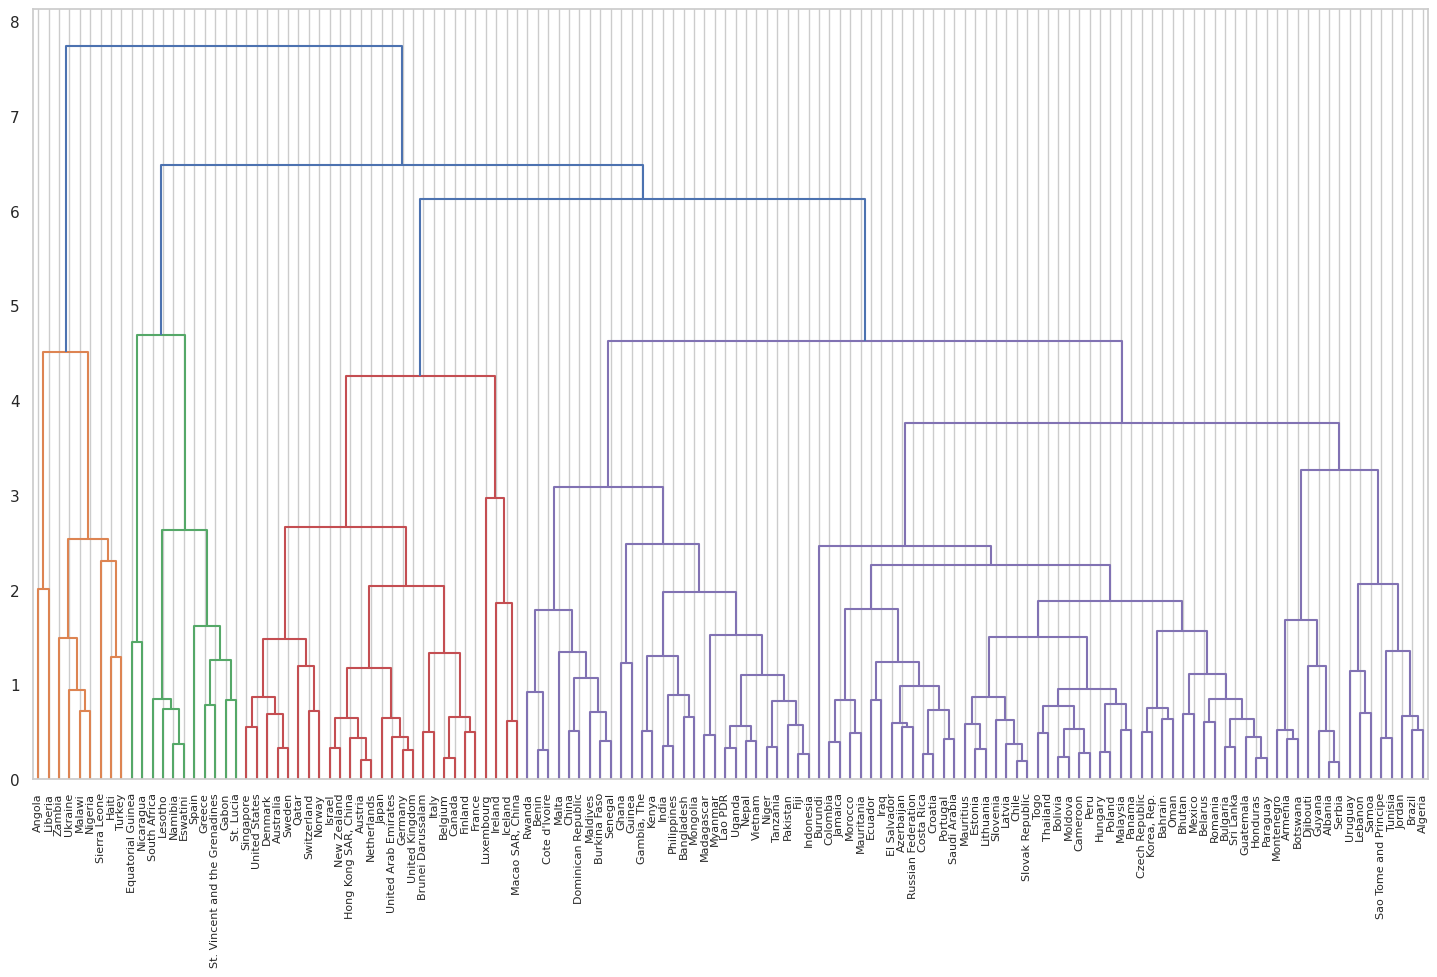

In [12]:
df_scaled = df.copy()
df_scaled.iloc[:, :] = StandardScaler().fit_transform(df)
Z = hierarchy.linkage(df_scaled, 'complete')
plt.figure(figsize=(18, 10))
plt.grid(axis='y')
dn = hierarchy.dendrogram(Z, labels=list(df.index), leaf_font_size=8)

In [13]:
paises_interesse = ['Brazil',
                    'China',
                    'Uruguay',
                    'Paraguay',
                    'Chile',
                    'Peru',
                    'Bolivia',
                    'Ecuador',
                    'Colombia',
                    'Germany',
                    'United States',
                    'United Kingdom',
                    'Poland']

df_paises = df_scaled.loc[paises_interesse, :]
print(df_paises.shape)


(13, 4)


## 2. Matriz de distâncias para os países selecionados

Agora vamos olhar com mais cuidado para os países selecionados. Essa etapa ajuda a entender quais países são mais próximos antes de aplicar qualquer algoritmo de agrupamento.

## Escolha de \(k\) no K-médias usando silhueta

O método do cotovelo usa a inércia, isto é, a soma das distâncias quadráticas das observações aos seus centroides. Como complemento, podemos usar o coeficiente médio de silhueta para comparar diferentes valores de \(k\).


## Inércia (Within-Cluster Sum of Squares)

A inércia mede a variabilidade das observações dentro de cada grupo, sendo definida por

$$
W(k)=\sum_{j=1}^{k}\sum_{i\in C_j}\|\mathbf{x}_i-\mathbf{c}_j\|^2,
$$

em que:

- $k$ é o número de clusters;
- $C_j$ representa o conjunto de observações do cluster $j$;
- $\mathbf{c}_j$ é o centróide do cluster $j$;
- $\|\mathbf{x}_i-\mathbf{c}_j\|^2$ é a distância euclidiana ao quadrado entre a observação e o centróide.

Quanto menor a inércia, mais compactos tendem a ser os clusters.

No método do cotovelo, calcula-se a inércia para diferentes valores de $k$. Escolhe-se o ponto em que a redução da inércia passa a ser pequena, formando um "cotovelo" na curva.

In [14]:
matriz_distancias_paises = pairwise_distances(df_paises, metric="euclidean")

matriz_distancias_paises_df = pd.DataFrame(
    matriz_distancias_paises,
    index=df_paises.index,
    columns=df_paises.index
)

matriz_distancias_paises_df

,Brazil,China,Uruguay,Paraguay,Chile,Peru,Bolivia,Ecuador,Colombia,Germany,United States,United Kingdom,Poland
Brazil,0.000000,2.929017,1.416309,1.858413e+00,1.703967,2.309467e+00,2.271055,1.919520,0.958957,2.488571,2.989782,2.218608,2.522977e+00
China,2.929017,0.000000,2.777775,1.436946e+00,1.304961,1.240139e+00,1.127187,2.435943,2.007102,2.890630,2.883679,2.755016,7.164099e-01
Uruguay,1.416309,2.777775,0.000000,1.539195e+00,1.750377,2.238591e+00,2.121942,2.258716,1.347434,2.236608,2.599291,1.945205,2.349420e+00
Paraguay,1.858413,1.436946,1.539195,1.053671e-08,0.783227,8.005284e-01,0.597204,1.513823,0.950478,2.213369,2.569037,1.963022,1.003000e+00
Chile,1.703967,1.304961,1.750377,7.832272e-01,0.000000,9.560871e-01,0.925966,1.574079,0.844933,1.985269,2.216893,1.775369,8.508235e-01
Peru,2.309467,1.240139,2.238591,8.005284e-01,0.956087,2.107342e-08,0.323345,1.255729,1.404859,2.159883,2.537469,1.981036,6.785566e-01
Bolivia,2.271055,1.127187,2.121942,5.972036e-01,0.925966,3.233453e-01,0.000000,1.452167,1.330216,2.345343,2.685707,2.144079,6.854765e-01
Ecuador,1.919520,2.435943,2.258716,1.513823e+00,1.574079,1.255729e+00,1.452167,0.000000,1.452202,1.922228,2.669727,1.730078,1.827310e+00
Colombia,0.958957,2.007102,1.347434,9.504778e-01,0.844933,1.404859e+00,1.330216,1.452202,0.000000,2.226491,2.664747,1.952931,1.605165e+00
Germany,2.488571,2.890630,2.236608,2.213369e+00,1.985269,2.159883e+00,2.345343,1.922228,2.226491,0.000000,0.931303,0.308864,2.216317e+00


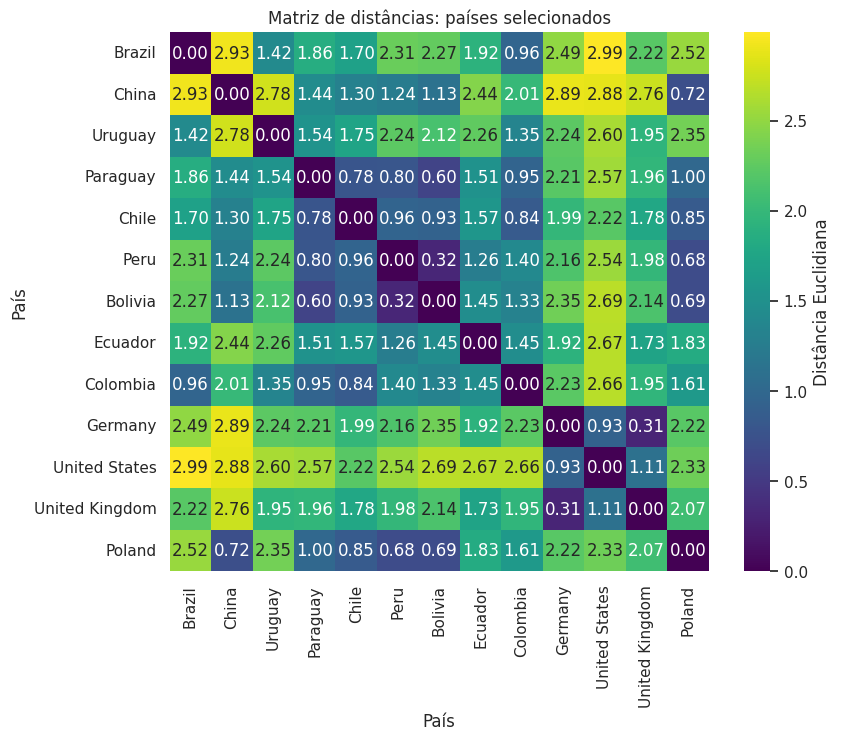

In [15]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_distancias_paises_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    cbar_kws={"label": "Distância Euclidiana"}
)
plt.title("Matriz de distâncias: países selecionados")
plt.xlabel("País")
plt.ylabel("País")
plt.show()

## 3. Dendrogramas e métodos de ligação

No agrupamento hierárquico, os países começam separados e vão sendo unidos de acordo com suas distâncias. O modo como a distância entre grupos é calculada depende do **método de ligação** (*linkage*).

Alguns métodos comuns são:

| Método | Ideia |
|---|---|
| `single` | distância mínima entre pontos de dois grupos |
| `complete` | distância máxima entre pontos de dois grupos |
| `average` | distância média entre pontos de dois grupos |
| `ward` | une grupos buscando minimizar o aumento da variância dentro dos grupos |

O método `ward` costuma formar grupos mais compactos, mas é interessante comparar com outros métodos.

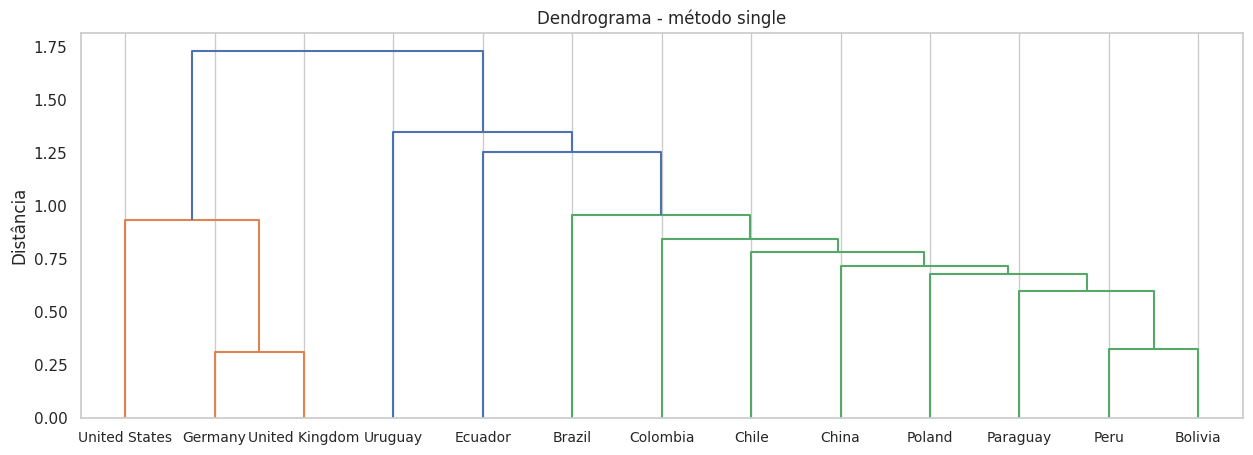

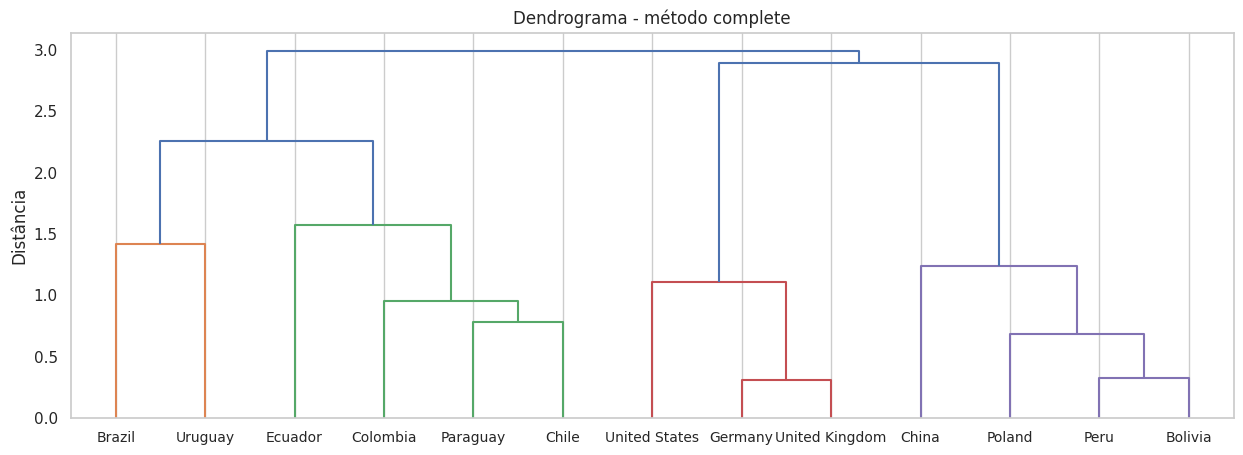

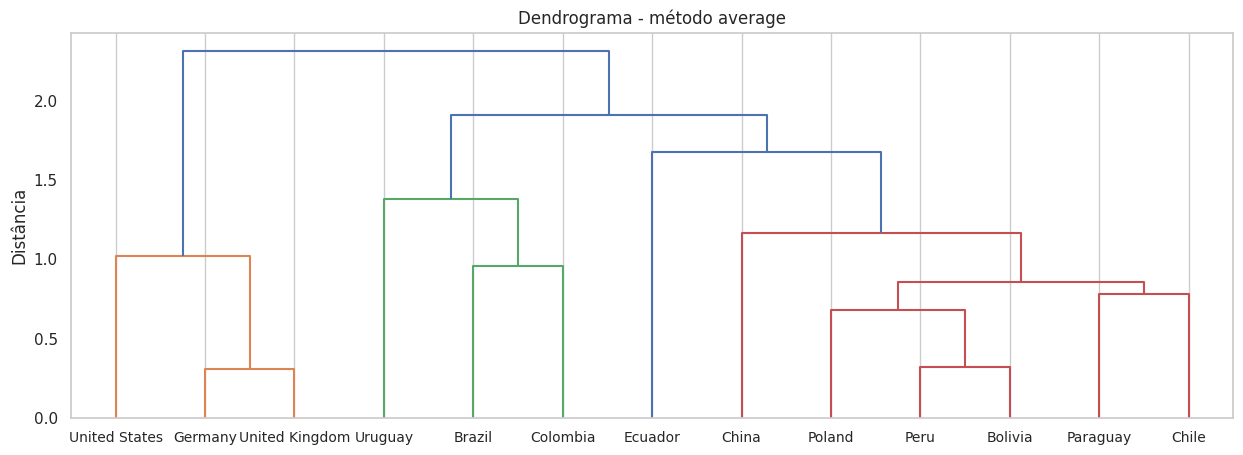

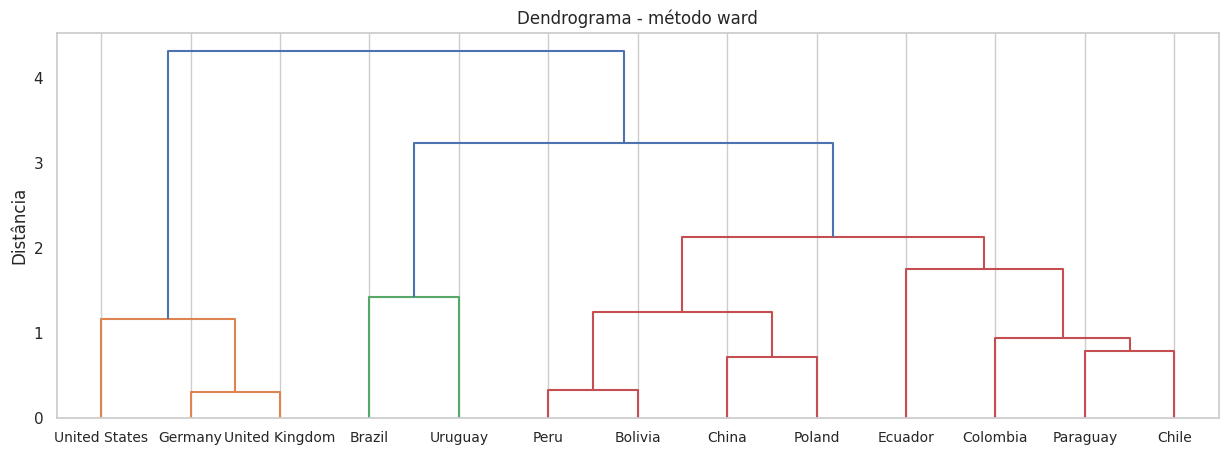

In [16]:
metodos = ["single", "complete", "average", "ward"]

for metodo in metodos:
    Z_metodo = hierarchy.linkage(df_paises, method=metodo)

    plt.figure(figsize=(15, 5))
    hierarchy.dendrogram(
        Z_metodo,
        labels=list(df_paises.index),
        leaf_font_size=10
    )
    plt.title(f"Dendrograma - método {metodo}")
    plt.ylabel("Distância")
    plt.grid(axis="y")
    plt.show()

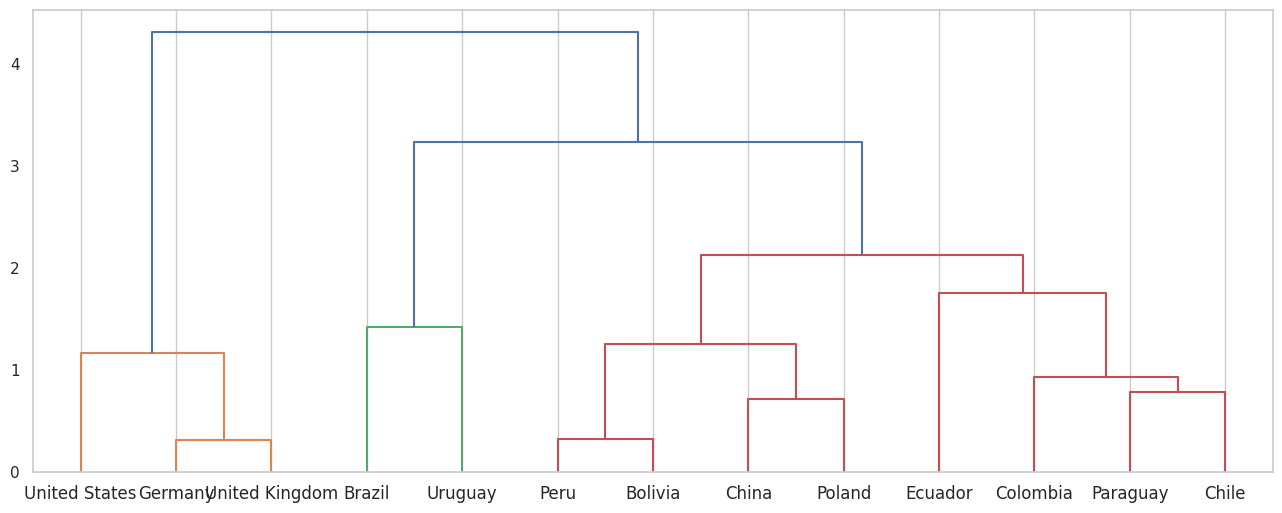

In [17]:
Z = hierarchy.linkage(df_paises, 'ward')
plt.figure(figsize=(16, 6))
plt.grid(axis='y')
dn = hierarchy.dendrogram(Z, labels=list(df_paises.index), leaf_font_size=12)



## 4. Avaliação com coeficiente de silhueta

O **coeficiente de silhueta** mede o quanto cada observação parece bem alocada ao seu grupo.

Para uma observação \(i\):

- \(a(i)\): distância média de \(i\) às observações do mesmo grupo;
- \(b(i)\): menor distância média de \(i\) às observações de outro grupo.

O coeficiente é dado por

$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}.
$$

A interpretação usual é:

| Valor | Interpretação |
|---|---|
| próximo de 1 | observação bem alocada |
| próximo de 0 | observação na fronteira entre grupos |
| negativo | possível alocação inadequada |

In [18]:
# Silhueta média para diferentes números de grupos no agrupamento hierárquico
silhueta_hierarquico = []
valores_k = range(2, 8)

for k in valores_k:
    modelo_h = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_h = modelo_h.fit_predict(df_paises)
    silhueta_hierarquico.append(silhouette_score(df_paises, labels_h))

pd.DataFrame({
    "k": list(valores_k),
    "silhueta_media": silhueta_hierarquico
})

,k,silhueta_media
0,2,0.424484
1,3,0.432507
2,4,0.292838
3,5,0.292667
4,6,0.269466
5,7,0.270434


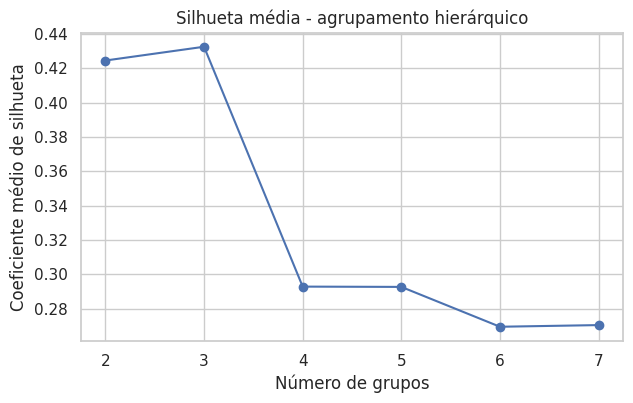

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(list(valores_k), silhueta_hierarquico, marker="o")
plt.xlabel("Número de grupos")
plt.ylabel("Coeficiente médio de silhueta")
plt.title("Silhueta média - agrupamento hierárquico")
plt.xticks(list(valores_k))
plt.grid(True)
plt.show()

In [20]:
n_clusters = 3
cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
groups = cluster.fit_predict(df_paises)



In [21]:
groups

array([2, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0])

In [22]:
countries = list(df_paises.index)
grouped_countries = {i: [] for i in range(n_clusters)}
for country, group in zip(countries, groups):
    grouped_countries[group].append(country)

for gp, ctr in grouped_countries.items():
    print(f'Cluster {gp}: {ctr}\n')

Cluster 0: ['China', 'Paraguay', 'Chile', 'Peru', 'Bolivia', 'Ecuador', 'Colombia', 'Poland']

Cluster 1: ['Germany', 'United States', 'United Kingdom']

Cluster 2: ['Brazil', 'Uruguay']



### Silhueta por país no agrupamento hierárquico escolhido

Além da média geral, podemos observar o coeficiente de silhueta de cada país. Valores baixos ou negativos indicam países que estão em regiões de fronteira entre grupos.

In [23]:
sil_paises_h = silhouette_samples(df_paises, groups)

silhueta_paises_h = pd.DataFrame({
    "pais": df_paises.index,
    "cluster": groups,
    "silhueta": sil_paises_h
}).sort_values(["cluster", "silhueta"])

silhueta_paises_h

,pais,cluster,silhueta
8,Colombia,0,-0.158686
7,Ecuador,0,0.212843
4,Chile,0,0.401162
3,Paraguay,0,0.404185
1,China,0,0.484031
12,Poland,0,0.523445
5,Peru,0,0.572657
6,Bolivia,0,0.581050
10,United States,1,0.603412
11,United Kingdom,1,0.654093


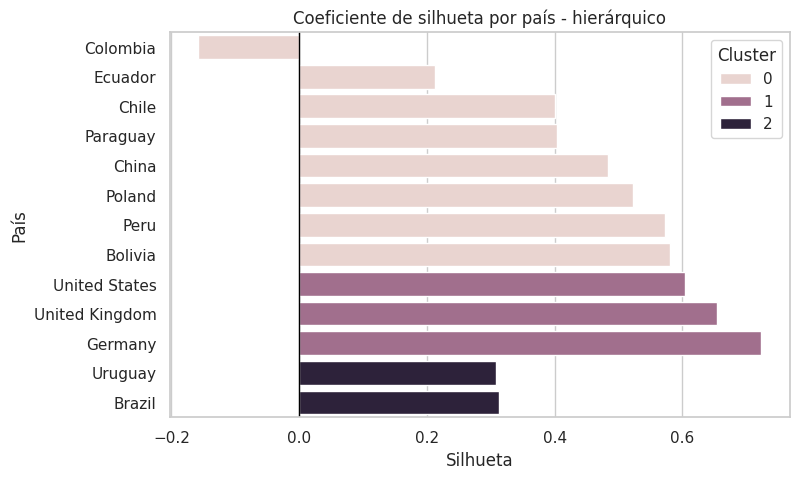

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=silhueta_paises_h,
    x="silhueta",
    y="pais",
    hue="cluster",
    dodge=False
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficiente de silhueta por país - hierárquico")
plt.xlabel("Silhueta")
plt.ylabel("País")
plt.legend(title="Cluster")
plt.show()

## Agrupamento não-hierárquico (K-médias)

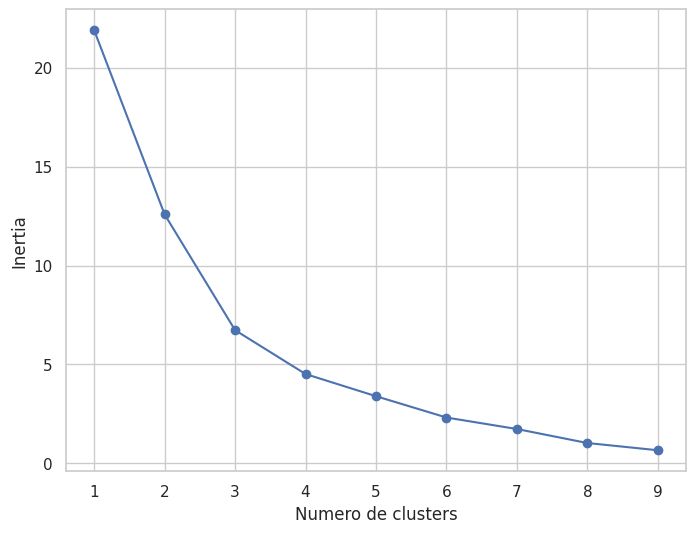

In [25]:
inertias = []
for k in np.arange(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    kmeans.fit(df_paises)
    inertias.append(kmeans.inertia_)

# Plotando o gráfico do Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, 10), inertias, '-o')
plt.xlabel('Numero de clusters')
plt.ylabel('Inertia');

In [26]:
silhueta_kmeans = []
valores_k = range(2, 8)

for k in valores_k:
    modelo_k = KMeans(n_clusters=k, random_state=10, n_init=10)
    labels_k = modelo_k.fit_predict(df_paises)
    silhueta_kmeans.append(silhouette_score(df_paises, labels_k))

pd.DataFrame({
    "k": list(valores_k),
    "silhueta_media": silhueta_kmeans
})

,k,silhueta_media
0,2,0.424484
1,3,0.442082
2,4,0.414534
3,5,0.385644
4,6,0.312591
5,7,0.265174


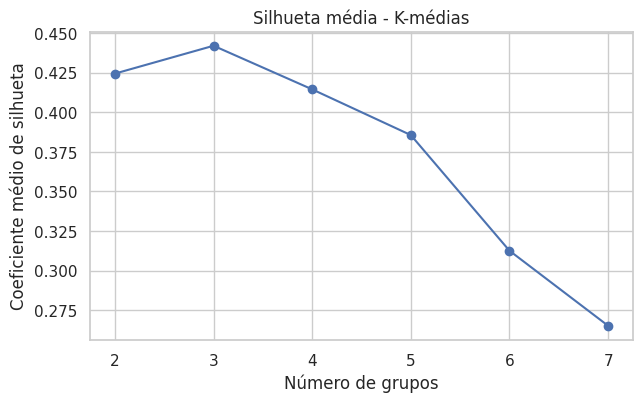

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(list(valores_k), silhueta_kmeans, marker="o")
plt.xlabel("Número de grupos")
plt.ylabel("Coeficiente médio de silhueta")
plt.title("Silhueta média - K-médias")
plt.xticks(list(valores_k))
plt.grid(True)
plt.show()

In [28]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)



### K-médias nos países selecionados

Para comparar diretamente com o agrupamento hierárquico, vamos ajustar o K-médias apenas aos países selecionados, usando o mesmo número de grupos.

In [29]:
n_clusters = 3
kmeans_paises = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)
groups_kmeans = kmeans_paises.fit_predict(df_paises)

groups_kmeans

array([2, 1, 2, 1, 1, 1, 1, 1, 2, 0, 0, 0, 1], dtype=int32)

In [30]:
grouped_countries_kmeans = {i: [] for i in range(n_clusters)}

for country, group in zip(df_paises.index, groups_kmeans):
    grouped_countries_kmeans[group].append(country)

for gp, ctr in grouped_countries_kmeans.items():
    print(f"Cluster {gp}: {ctr}")

Cluster 0: ['Germany', 'United States', 'United Kingdom']
Cluster 1: ['China', 'Paraguay', 'Chile', 'Peru', 'Bolivia', 'Ecuador', 'Poland']
Cluster 2: ['Brazil', 'Uruguay', 'Colombia']


### Centroides do K-médias

No K-médias, cada grupo é representado por um **centroide**, que pode ser interpretado como o perfil médio padronizado dos países daquele grupo.

Como os dados estão padronizados:

- valores positivos indicam que o cluster está acima da média geral naquela variável;
- valores negativos indicam que o cluster está abaixo da média geral naquela variável.

In [31]:
centroides = pd.DataFrame(
    kmeans_paises.cluster_centers_,
    columns=df_paises.columns
)

centroides.index = [f"Cluster {i}" for i in range(n_clusters)]
centroides

,inflacao,pib_per_capita,crescimento_pib,desemprego
Cluster 0,-0.371590,1.480645,-0.682304,-0.574554
Cluster 1,-0.425480,-0.374572,0.330112,-0.477353
Cluster 2,0.337125,-0.293659,-0.724956,0.564084


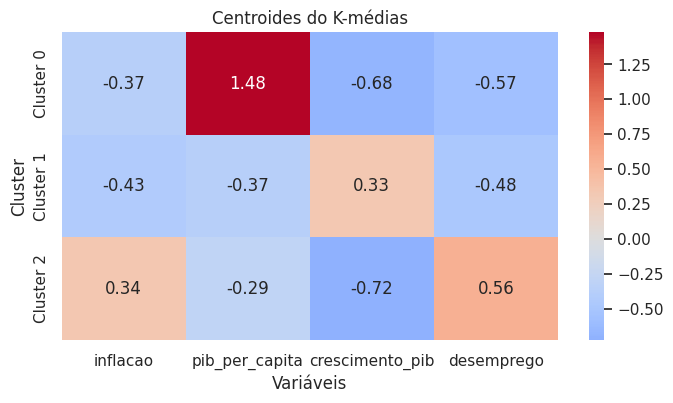

In [32]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    centroides,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Centroides do K-médias")
plt.xlabel("Variáveis")
plt.ylabel("Cluster")
plt.show()

### Silhueta por país no K-médias

In [33]:
sil_paises_k = silhouette_samples(df_paises, groups_kmeans)

silhueta_paises_k = pd.DataFrame({
    "pais": df_paises.index,
    "cluster": groups_kmeans,
    "silhueta": sil_paises_k
}).sort_values(["cluster", "silhueta"])

silhueta_paises_k

,pais,cluster,silhueta
10,United States,0,0.601316
11,United Kingdom,0,0.652719
9,Germany,0,0.724110
7,Ecuador,1,0.106726
4,Chile,1,0.256254
3,Paraguay,1,0.294548
1,China,1,0.464500
6,Bolivia,1,0.553455
12,Poland,1,0.555267
5,Peru,1,0.558671


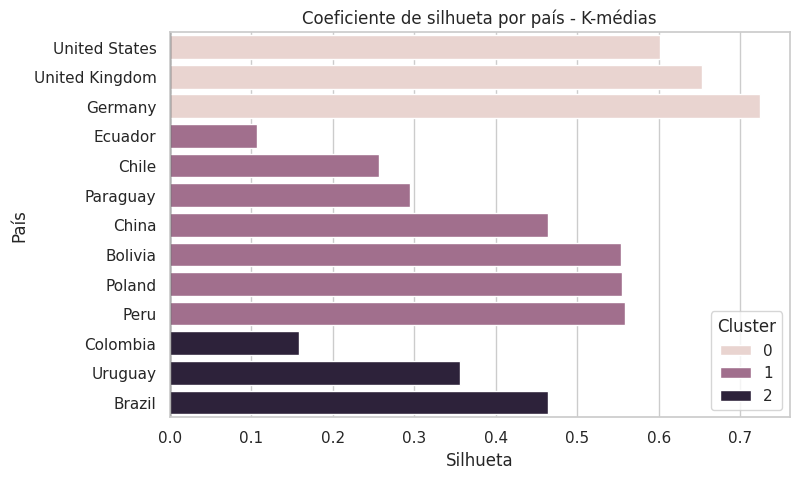

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=silhueta_paises_k,
    x="silhueta",
    y="pais",
    hue="cluster",
    dodge=False
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficiente de silhueta por país - K-médias")
plt.xlabel("Silhueta")
plt.ylabel("País")
plt.legend(title="Cluster")
plt.show()

## 7. Comparação entre agrupamento hierárquico e K-médias

| Aspecto | Hierárquico | K-médias |
|---|---|---|
| Precisa definir \(k\) antes? | Não necessariamente | Sim |
| Representação visual típica | Dendrograma | Gráfico dos grupos e centroides |
| Base do método | Distâncias e ligações sucessivas | Centroides |
| Custo computacional | Mais alto em bases grandes | Mais baixo |
| Interpretação | Boa, especialmente pelo dendrograma | Boa pelos centroides |
| Sensível à escala? | Sim | Sim |

Na prática, é recomendável combinar diferentes ferramentas:

1. matriz de distâncias para entender proximidades;
2. dendrograma para visualizar a estrutura hierárquica;
3. cotovelo para avaliar a redução da inércia;
4. silhueta para avaliar a qualidade dos grupos;
5. centroides para interpretar os perfis dos grupos no K-médias.



In [35]:
df_scaled

,inflacao,pib_per_capita,crescimento_pib,desemprego,cluster
United Arab Emirates,-0.130461,1.122580,-0.893730,-0.797911,2
Albania,-0.407292,-0.545334,0.268457,1.317281,1
Armenia,-0.275282,-0.591352,0.806902,2.029755,1
Angola,4.395172,-0.625800,-2.495812,0.075963,1
Austria,-0.413215,1.498476,-0.305901,-0.384885,2
...,...,...,...,...,...
St. Vincent and the Grenadines,-0.327111,-0.451490,-0.383446,2.412518,1
Vietnam,-0.005894,-0.664174,1.651683,-0.925685,0
Samoa,0.168031,-0.583382,-1.208869,0.276217,1
South Africa,0.249206,-0.495834,-1.180513,3.756953,1


In [36]:
countries = list(df_scaled.index)
groups = df_scaled['cluster']

grouped_countries = {i: [] for i in range(n_clusters)}

for country, group in zip(countries, groups):
    grouped_countries[group].append(country)

for gp, ctr in grouped_countries.items():
    print(f'Cluster {gp}: {ctr}\n')



Cluster 0: ['Azerbaijan', 'Bangladesh', 'Burkina Faso', 'Bulgaria', 'Burundi', 'Benin', 'Bolivia', 'Bhutan', 'Belarus', "Cote d'Ivoire", 'Chile', 'Cameroon', 'China', 'Costa Rica', 'Czech Republic', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Estonia', 'Fiji', 'Ghana', 'Gambia, The', 'Guinea', 'Guatemala', 'Honduras', 'Croatia', 'Hungary', 'Indonesia', 'India', 'Kenya', 'Lao PDR', 'Sri Lanka', 'Lithuania', 'Latvia', 'Morocco', 'Moldova', 'Madagascar', 'Myanmar', 'Mongolia', 'Mauritania', 'Malta', 'Mauritius', 'Maldives', 'Mexico', 'Malaysia', 'Niger', 'Nepal', 'Oman', 'Panama', 'Peru', 'Philippines', 'Pakistan', 'Poland', 'Paraguay', 'Romania', 'Russian Federation', 'Rwanda', 'Saudi Arabia', 'Slovenia', 'Slovak Republic', 'Senegal', 'El Salvador', 'Togo', 'Thailand', 'Tanzania', 'Uganda', 'Vietnam', 'Zambia']

Cluster 1: ['Albania', 'Armenia', 'Angola', 'Brazil', 'Botswana', 'Colombia', 'Algeria', 'Spain', 'Gabon', 'Equatorial Guinea', 'Greece', 'Guyana', 'Haiti', 'Iraq', 'Jamaica', 

In [37]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

world = world[["NAME", "geometry"]]
world = world.rename(columns={"NAME": "name"})

world.head()

,name,geometry
0,Fiji,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [38]:
world

,name,geometry
0,Fiji,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...
172,Serbia,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,Montenegro,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
174,Kosovo,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,Trinidad and Tobago,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


In [39]:
# Alguns paises possuem nomes diferentes nos dois conjutos, estamos corrigindo isso
world.loc[world['name'] == 'Brunei', 'name'] = 'Brunei Darussalam'
world.loc[world['name'] == "Côte d'Ivoire", 'name'] = "Cote d'Ivoire"
world.loc[world['name'] == "Czechia", 'name'] = "Czech Republic"
world.loc[world['name'] == "Dominican Rep.", 'name'] = "Dominican Republic"
world.loc[world['name'] == "Gambia", 'name'] = "Gambia, The"
world.loc[world['name'] == "Guinea", 'name'] = "Equatorial Guinea"
world.loc[world['name'] == "Russia", 'name'] = "Russian Federation"
world.loc[world['name'] == "United States of America", 'name'] ="United States"

In [41]:
world.head()

,name,geometry
0,Fiji,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Tanzania,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,W. Sahara,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [44]:
df_scaled.head()

,inflacao,pib_per_capita,crescimento_pib,desemprego,cluster
United Arab Emirates,-0.130461,1.122580,-0.893730,-0.797911,2
Albania,-0.407292,-0.545334,0.268457,1.317281,1
Armenia,-0.275282,-0.591352,0.806902,2.029755,1
Angola,4.395172,-0.625800,-2.495812,0.075963,1
Austria,-0.413215,1.498476,-0.305901,-0.384885,2


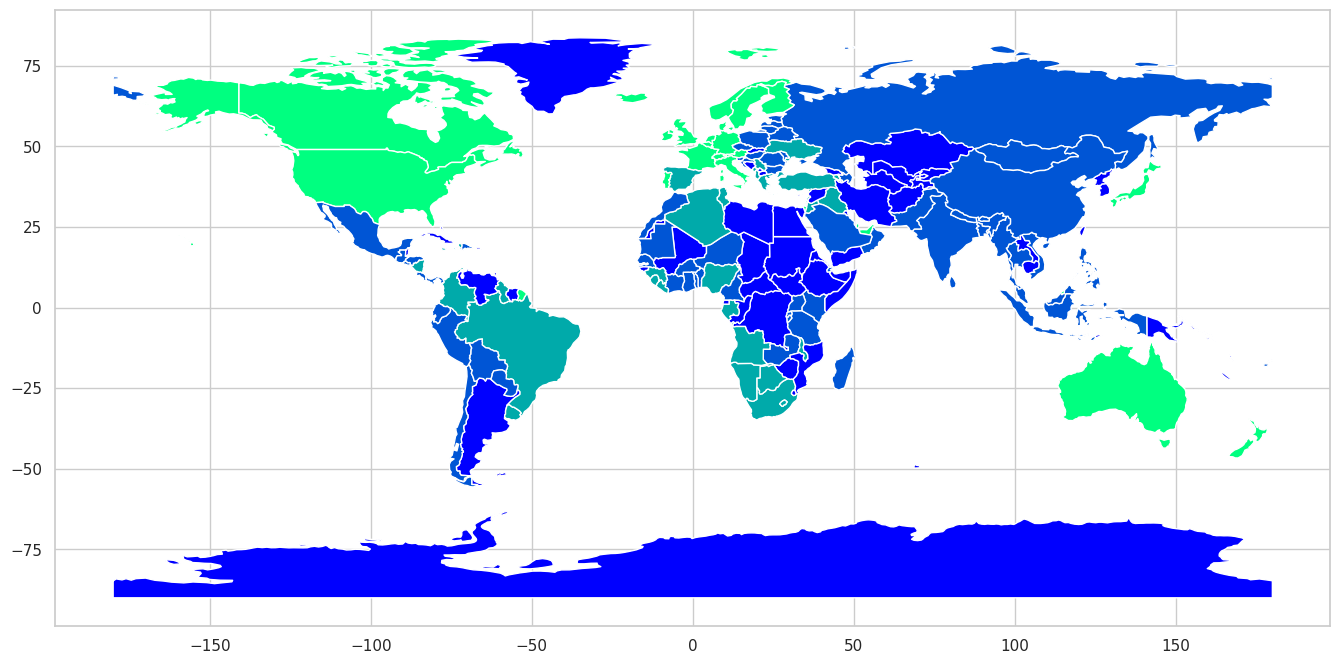

In [42]:
# Juntando os dois conjuntos
all_data = pd.merge(world, df_scaled.reset_index(), how='left', left_on='name', right_on='index')

# Indicando os países que não temos dados (Serão plotados em preto)
all_data.loc[:, 'cluster'] = all_data.loc[:, 'cluster'].fillna(-1)

# Plotando o gráfico
all_data.plot(column='cluster', figsize=(18, 8), cmap='winter');